In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

In [3]:
iris = load_iris()

In [4]:
pca =PCA(n_components=2)

In [5]:
iris_pca = pca.fit_transform(iris.data)

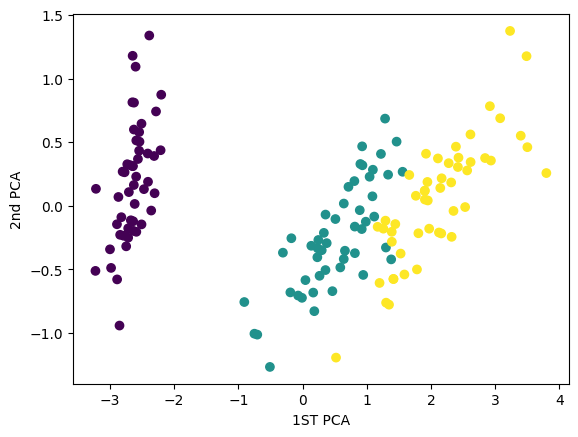

In [6]:
plt.scatter(iris_pca[:,0], iris_pca[:,1], c=iris.target)
plt.xlabel('1ST PCA')
plt.ylabel('2nd PCA')
plt.show()

## on tips dataset

In [7]:
df = sns.load_dataset('tips')

In [9]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [11]:
# Preprocessing
# Encoding
le = LabelEncoder()
cat_features = df.select_dtypes(include='category').columns

for features in cat_features:
    df[features] = le.fit_transform(df[features])

# satndardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(df_scaled)

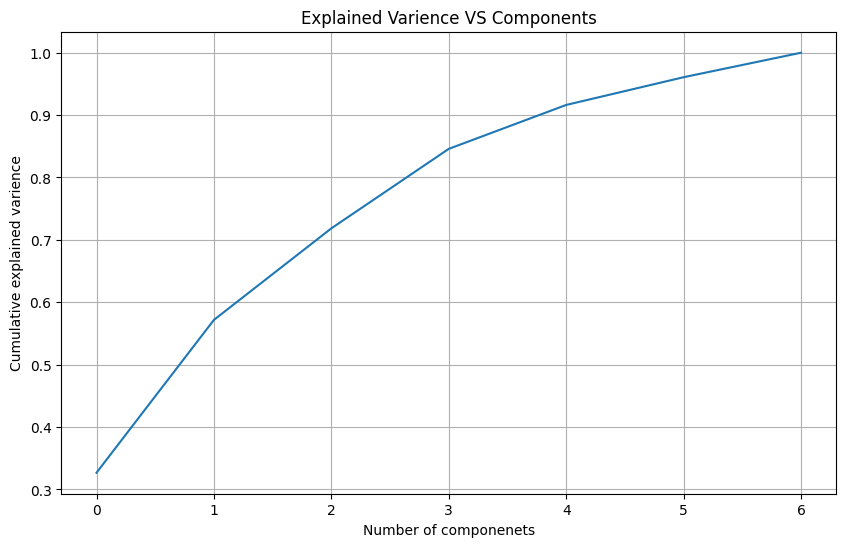

In [15]:
# Plot the explained varience ratio
plt.figure(figsize=(10,6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title('Explained Varience VS Components')
plt.xlabel('Number of componenets')
plt.ylabel('Cumulative explained varience')
plt.grid(True)
plt.show()

In [17]:
# Create a dataframe to show the loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=df.columns
)

print(loadings)

                 PC1       PC2       PC3       PC4       PC5       PC6  \
total_bill  0.577289  0.133642  0.164816  0.061756 -0.058183  0.378659   
tip         0.531650  0.178333  0.159316 -0.010375 -0.637807 -0.274214   
sex         0.189111 -0.152571 -0.588523  0.762364  0.000506 -0.115541   
smoker      0.036649 -0.335732  0.724260  0.501763  0.212334  0.111732   
day        -0.156579  0.660434 -0.047053  0.229846  0.003218  0.606759   
time       -0.281249  0.556479  0.266919  0.297170 -0.004329 -0.572115   
size        0.493317  0.261729 -0.055523 -0.148236  0.738039 -0.245190   

                 PC7  
total_bill  0.686390  
tip        -0.421978  
sex         0.007162  
smoker     -0.228151  
day        -0.340735  
time        0.352618  
size       -0.241370  


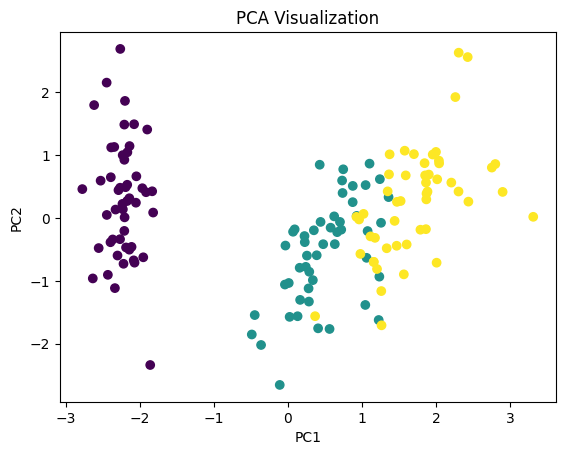

In [18]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

iris = load_iris()
X = iris.data
y = iris.target

X = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")
plt.show()